<a href="https://colab.research.google.com/github/Naganarthanan/RiceGuard-DL/blob/main/CommonDataSetForRiceGuard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install kaggle -q
!kaggle datasets download -d anshulm257/rice-disease-dataset
!unzip -q rice-disease-dataset.zip -d rice_disease

Dataset URL: https://www.kaggle.com/datasets/anshulm257/rice-disease-dataset
License(s): unknown
rice-disease-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace rice_disease/Rice_Leaf_AUG/Bacterial Leaf Blight/20231006_164208.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [3]:
!ls rice_disease

Rice_Leaf_AUG


In [4]:
!ls rice_disease/rice_disease

ls: cannot access 'rice_disease/rice_disease': No such file or directory


In [5]:
import os

data_dir = 'rice_disease'  # Step 4-ல பார்த்த சரியான path போடுங்க

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        print(f"{class_name}: {num_images} images")

Rice_Leaf_AUG: 6 images


In [6]:
from PIL import Image
import os

data_dir = 'rice_disease'
removed_count = 0

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            if os.path.isfile(img_path):  # Add this check to ensure it's a file
                try:
                    img = Image.open(img_path)
                    img.verify()  # image valid-ஆ இருக்கான்னு check பண்ணும்
                except Exception:
                    print(f"Removing corrupted image: {img_path}")
                    os.remove(img_path)
                    removed_count += 1

print(f"\nTotal corrupted images removed: {removed_count}")


Total corrupted images removed: 0


In [7]:
import hashlib
import os

def get_file_hash(filepath):
    with open(filepath, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

data_dir = 'rice_disease'
hashes = {}
duplicates = 0

for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)
            if os.path.isfile(img_path):  # Add this check
                file_hash = get_file_hash(img_path)
                if file_hash in hashes:
                    os.remove(img_path)  # duplicate-ஐ நீக்குறது
                    duplicates += 1
                else:
                    hashes[file_hash] = img_path

print(f"Total duplicate images removed: {duplicates}")

Total duplicate images removed: 0


In [8]:
import splitfolders

splitfolders.ratio('rice_disease/Rice_Leaf_AUG', output='rice_disease_split',
                    seed=42, ratio=(0.7, 0.15, 0.15))  # 70% train, 15% val, 15% test

!ls rice_disease_split

Copying files: 3829 files [00:05, 698.72 files/s]


test  train  val


In [9]:
import os

data_dir = 'rice_disease_split/train'
classes = os.listdir(data_dir)
print("Classes found:", classes)

for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        print(f"{class_name}: {len(os.listdir(class_path))} images")
    else:
        print(f"{class_name}: NOT A FOLDER (this is the problem!)")

Classes found: ['Rice_Leaf_AUG', 'Leaf scald', 'Bacterial Leaf Blight', 'Healthy Rice Leaf', 'Leaf Blast', 'Sheath Blight', 'Brown Spot']
Rice_Leaf_AUG: 0 images
Leaf scald: 439 images
Bacterial Leaf Blight: 445 images
Healthy Rice Leaf: 457 images
Leaf Blast: 443 images
Sheath Blight: 442 images
Brown Spot: 452 images


Valid classes: ['Leaf scald', 'Bacterial Leaf Blight', 'Healthy Rice Leaf', 'Leaf Blast', 'Sheath Blight', 'Brown Spot']


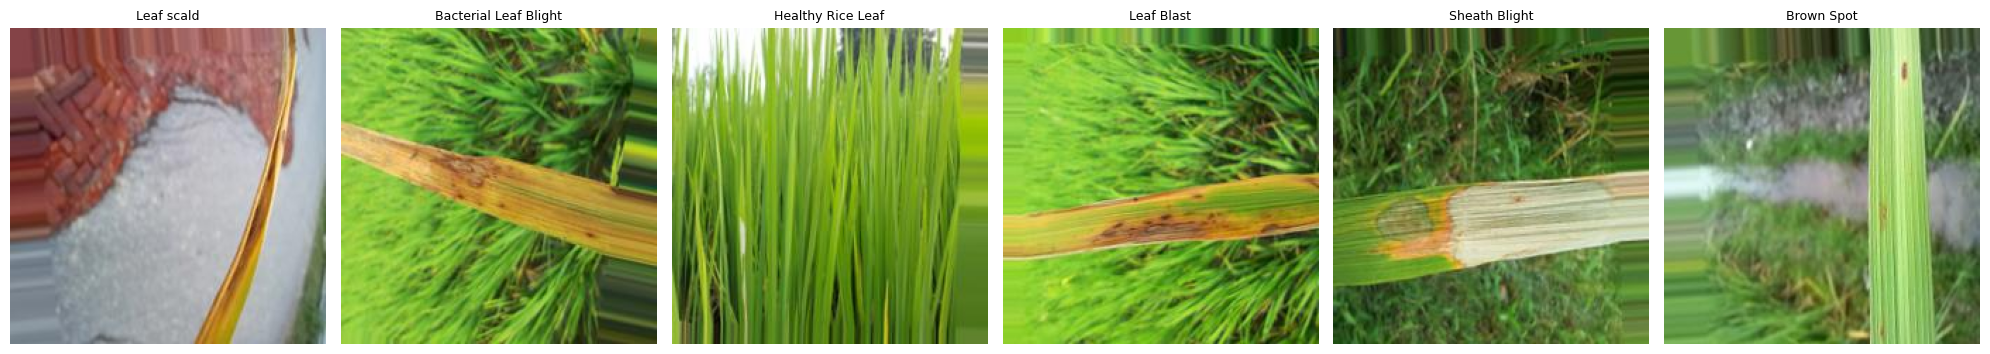

In [10]:
import matplotlib.pyplot as plt
import os
from PIL import Image

data_dir = 'rice_disease_split/train'

# Only valid folders with at least 1 image எடுக்கும்
classes = [c for c in os.listdir(data_dir)
           if os.path.isdir(os.path.join(data_dir, c))
           and len(os.listdir(os.path.join(data_dir, c))) > 0]

print("Valid classes:", classes)

fig, axes = plt.subplots(1, len(classes), figsize=(20, 4))
for idx, class_name in enumerate(classes):
    class_path = os.path.join(data_dir, class_name)
    img_name = os.listdir(class_path)[0]
    img = Image.open(os.path.join(class_path, img_name))
    axes[idx].imshow(img)
    axes[idx].set_title(class_name, fontsize=9)
    axes[idx].axis('off')
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()

In [11]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r rice_disease_split /content/drive/MyDrive/RiceGuard_DL/rice_disease_split

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot create directory '/content/drive/MyDrive/RiceGuard_DL/rice_disease_split': No such file or directory
